# Fine-tuning del Swin-Tiny en el dominio externo (Croacia)

**Objetivo:** adaptar el Swin-Tiny sagital (entrenado en MRNet) al segundo hospital
(Rijeka, Croacia; Štajduhar et al., 2017) y medir la mejora sobre el **test de Croacia**.

Este notebook corrige y sustituye el fine-tuning que había en
`Threshold_Tuning_and_External_Validation.ipynb`, donde el "test" apuntaba por error
al test de MRNet. Aquí todo se evalúa sobre el **subconjunto de test de Croacia**
(138 casos held-out), verificado como Croacia y no MRNet.

**Receta:** se parte del checkpoint canónico multiseed, se congela el backbone unas
épocas (warm-up del cabezal) y luego ajuste completo con *learning rate* discriminativo
(backbone < cabezal), `pos_weight` para el desbalance, selección del mejor epoch por AUC
de validación y *early stopping*. Se repite con **5 semillas** y se reporta cada una,
su media y el **ensamble** (promedio de probabilidades + TTA por volteo horizontal).

**Baselines a batir:** zero-shot del propio Swin (~0.897 en el test-138) y el
fine-tuning del ResNet50 de la memoria (0.899).

## 1. Importaciones y configuración

In [1]:
import os, sys, json, copy, random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import roc_auc_score, precision_recall_curve, confusion_matrix, roc_curve
import matplotlib.pyplot as plt

BASE = Path('/home/palodo2/acl_classifier')
sys.path.insert(0, str(BASE))
os.chdir(BASE)
from src.models import SwinMultiSliceClassifier

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CROATIA_DIR = BASE / 'data' / 'croatia_npy_volumes_full'
SPLITS = CROATIA_DIR / 'splits'
IDX = SPLITS / 'slice_indices'
CANON = BASE / 'checkpoints' / 'swin_tiny_multiseed' / 'best_sagittal_multiseed_final.pth'
OUT = SPLITS / 'finetune_v2'
OUT.mkdir(parents=True, exist_ok=True)

# Hiperparámetros del fine-tuning
SEEDS       = [42, 43, 44, 45, 46]
EPOCHS      = 25
FREEZE_EP   = 3       # épocas con backbone congelado (solo cabezal + pooling)
LR_HEAD     = 3e-4
LR_BACKBONE = 3e-5    # LR discriminativo: backbone 10x menor
WEIGHT_DECAY= 1e-4
PATIENCE    = 7

print('Device:', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

/home/palodo2/acl_classifier/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:11: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.sparse import csr_matrix, issparse


Device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti


## 2. Datos y splits

Se reutilizan los splits e índices de cortes ya cacheados
(`splits/{train,val,test}.csv` y `splits/slice_indices/`), generados con el selector CNN
de cortes sobre los volúmenes sagitales de Croacia. Así el resultado es comparable con la
corrida previa. **Verificación de procedencia:** los `volume_id` del test trazan a los
ficheros originales `.pck` de Croacia.

In [2]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
norm = transforms.Normalize(mean=MEAN, std=STD)
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    norm,
])
eval_tf = transforms.Compose([transforms.Resize((224, 224)), norm])


def load_vol(p):
    v = np.load(p).astype(np.float32)
    lo, hi = v.min(), v.max()
    return (v - lo) / (hi - lo) if hi > lo else v


class CroatiaSplit(Dataset):
    def __init__(self, csv, idx_json, tf):
        self.df = pd.read_csv(csv)
        self.idx = json.load(open(idx_json))
        self.tf = tf

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r = self.df.iloc[i]
        vol = load_vol(CROATIA_DIR / r['filename'])
        sl = vol[self.idx[str(r['volume_id'])]]
        sl = torch.from_numpy(sl).float().unsqueeze(1).repeat(1, 3, 1, 1)
        sl = torch.stack([self.tf(s) for s in sl], 0)
        return sl, torch.tensor(float(r['label'])), str(r['volume_id'])


def make_loaders():
    tr = CroatiaSplit(SPLITS / 'train.csv', IDX / 'train_sagittal_indices.json', train_tf)
    va = CroatiaSplit(SPLITS / 'val.csv',   IDX / 'val_sagittal_indices.json',   eval_tf)
    te = CroatiaSplit(SPLITS / 'test.csv',  IDX / 'test_sagittal_indices.json',  eval_tf)
    g = torch.Generator(); g.manual_seed(0)
    return (DataLoader(tr, 16, shuffle=True, num_workers=4, pin_memory=True, generator=g),
            DataLoader(va, 16, shuffle=False, num_workers=4, pin_memory=True),
            DataLoader(te, 16, shuffle=False, num_workers=4, pin_memory=True))

# Tamaños y distribución de clases
meta = pd.read_csv(CROATIA_DIR / 'metadata_final.csv').set_index('volume_id')
for name in ['train', 'val', 'test']:
    df = pd.read_csv(SPLITS / f'{name}.csv')
    d = df['label'].value_counts().to_dict()
    print(f'{name:>5}: {len(df):3d} casos  |  sano={d.get(0,0)}  rotura={d.get(1,0)}')

# Verificación de procedencia (Croacia, no MRNet)
test_df = pd.read_csv(SPLITS / 'test.csv')
in_croatia = test_df['volume_id'].isin(meta.index).sum()
print(f'\nProcedencia: {in_croatia}/{len(test_df)} volume_id del test están en la metadata de Croacia')
print('Ejemplos (volume_id -> fichero original .pck de Rijeka):')
for vid in test_df['volume_id'].head(4):
    print(f"  {vid:>4} -> {meta.loc[vid, 'original_filename']}  [{meta.loc[vid, 'diagnosis_3class_name']}]")

train: 641 casos  |  sano=482  rotura=159
  val: 138 casos  |  sano=104  rotura=34
 test: 138 casos  |  sano=104  rotura=34

Procedencia: 138/138 volume_id del test están en la metadata de Croacia
Ejemplos (volume_id -> fichero original .pck de Rijeka):
     1 -> 390116-9.pck  [Healthy (No Roto)]
     6 -> 415102-9.pck  [Healthy (No Roto)]
    11 -> 451760-9.pck  [Partially Injured (Lesión Parcial)]
    12 -> 454319-8.pck  [Partially Injured (Lesión Parcial)]


## 3. Modelo y baseline *zero-shot*

Se carga el Swin-Tiny sagital canónico (multiseed) y se mide su AUC en el test de Croacia
**sin reentrenar** (los avisos de *missing keys* son buffers no persistentes de Swin,
inofensivos).

In [3]:
def build_model():
    m = SwinMultiSliceClassifier()
    ck = torch.load(CANON, map_location='cpu', weights_only=False)
    sd = ck['model_state_dict'] if isinstance(ck, dict) and 'model_state_dict' in ck else ck
    m.load_state_dict(sd, strict=False)
    return m.to(DEVICE)


def fwd(model, x):
    out = model(x)
    return out[0] if isinstance(out, tuple) else out


@torch.no_grad()
def predict(model, loader, tta=False):
    model.eval()
    ps, ys = [], []
    for x, y, _ in loader:
        x = x.to(DEVICE)
        prob = torch.sigmoid(fwd(model, x))
        if tta:
            prob = 0.5 * (prob + torch.sigmoid(fwd(model, torch.flip(x, dims=[-1]))))
        ps.append(prob.cpu().numpy().ravel()); ys.append(y.numpy().ravel())
    return np.concatenate(ps), np.concatenate(ys)


_, _, te0 = make_loaders()
zs_probs, zs_labels = predict(build_model(), te0)
ZERO_SHOT_AUC = roc_auc_score(zs_labels, zs_probs)
print(f'Zero-shot Swin-Tiny sagital -> test Croacia (138): AUC = {ZERO_SHOT_AUC:.4f}')

/home/palodo2/acl_classifier/.venv/lib/python3.12/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4382.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Zero-shot Swin-Tiny sagital -> test Croacia (138): AUC = 0.8968


## 4. Fine-tuning multi-semilla

Para cada semilla: se reinicia desde el checkpoint canónico, se congela el backbone
`FREEZE_EP` épocas, luego ajuste completo con LR discriminativo y *cosine annealing*.
Se guarda el mejor estado por AUC de validación y se evalúa en test con TTA.

In [4]:
def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)


def pos_weight(loader):
    ys = np.concatenate([y.numpy().ravel() for _, y, _ in loader])
    n_pos = ys.sum(); n_neg = len(ys) - n_pos
    return torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32, device=DEVICE)


def train_one(seed):
    set_seed(seed)
    tr, va, te = make_loaders()
    model = build_model()
    crit = nn.BCEWithLogitsLoss(pos_weight=pos_weight(tr))
    groups = [
        {'params': [p for n, p in model.named_parameters() if n.startswith('backbone.')], 'lr': LR_BACKBONE},
        {'params': [p for n, p in model.named_parameters() if not n.startswith('backbone.')], 'lr': LR_HEAD},
    ]
    opt = torch.optim.AdamW(groups, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-6)

    best_auc, best_state, best_ep, bad = -1.0, None, -1, 0
    for ep in range(1, EPOCHS + 1):
        for p in model.backbone.parameters():
            p.requires_grad = ep > FREEZE_EP
        model.train()
        for x, y, _ in tr:
            x, y = x.to(DEVICE), y.to(DEVICE).view(-1, 1)
            opt.zero_grad()
            loss = crit(fwd(model, x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sched.step()
        vp, vy = predict(model, va)
        vauc = roc_auc_score(vy, vp)
        if vauc > best_auc:
            best_auc, best_state, best_ep, bad = vauc, copy.deepcopy(model.state_dict()), ep, 0
        else:
            bad += 1
        if bad >= PATIENCE:
            break

    model.load_state_dict(best_state)
    tp, ty = predict(model, te, tta=True)
    vp, vy = predict(model, va, tta=True)
    tauc = roc_auc_score(ty, tp)
    torch.save({'model_state_dict': best_state, 'seed': seed, 'val_auc': best_auc,
                'test_auc_tta': tauc}, OUT / f'ft_swin_croatia_seed{seed}.pth')
    print(f'seed {seed}: best val AUC={best_auc:.4f} (ep{best_ep})  |  test AUC(TTA)={tauc:.4f}')
    return {'seed': seed, 'best_ep': best_ep, 'val_auc': float(best_auc),
            'test_auc_tta': float(tauc), 'test_probs': tp, 'test_labels': ty,
            'val_probs': vp, 'val_labels': vy}


runs = [train_one(s) for s in SEEDS]

seed 42: best val AUC=0.9084 (ep7)  |  test AUC(TTA)=0.9248


seed 43: best val AUC=0.9160 (ep6)  |  test AUC(TTA)=0.9381


seed 44: best val AUC=0.9183 (ep7)  |  test AUC(TTA)=0.9350


seed 45: best val AUC=0.9016 (ep7)  |  test AUC(TTA)=0.9293


seed 46: best val AUC=0.9112 (ep7)  |  test AUC(TTA)=0.9273


## 5. Resultados: por semilla, media y ensamble

El umbral operativo se elige en la validación de Croacia (máximo F1) y se aplica al test.

In [5]:
def best_f1_threshold(y, p):
    prec, rec, thr = precision_recall_curve(y, p)
    f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-8)
    return float(thr[int(np.nanargmax(f1))]) if len(thr) else 0.5


ty = runs[0]['test_labels']; vy = runs[0]['val_labels']
ens_test = np.mean([r['test_probs'] for r in runs], axis=0)
ens_val  = np.mean([r['val_probs']  for r in runs], axis=0)
thr = best_f1_threshold(vy, ens_val)

pred = (ens_test >= thr).astype(int)
cm = confusion_matrix(ty.astype(int), pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
ens_auc = roc_auc_score(ty, ens_test)
aucs = [r['test_auc_tta'] for r in runs]

summary = {
    'zero_shot_test_auc': float(ZERO_SHOT_AUC),
    'resnet_ft_reference': 0.8993,
    'per_seed': [{'seed': r['seed'], 'best_ep': r['best_ep'],
                  'val_auc': r['val_auc'], 'test_auc_tta': r['test_auc_tta']} for r in runs],
    'seed_test_auc_mean': float(np.mean(aucs)),
    'seed_test_auc_std': float(np.std(aucs)),
    'seed_test_auc_best': float(np.max(aucs)),
    'ensemble_test': {'auc': float(ens_auc), 'threshold': float(thr),
                      'recall': float(tp / (tp + fn)), 'precision': float(tp / (tp + fp)),
                      'specificity': float(tn / (tn + fp)), 'cm': cm.tolist()},
}
json.dump(summary, open(OUT / 'summary.json', 'w'), indent=2)
pd.DataFrame({'label': ty, 'prob': ens_test}).to_csv(OUT / 'ensemble_test_predictions.csv', index=False)

tbl = pd.DataFrame(summary['per_seed'])
tbl = pd.concat([tbl, pd.DataFrame([{'seed': 'MEDIA', 'best_ep': '', 'val_auc': np.nan,
                                     'test_auc_tta': np.mean(aucs)},
                                    {'seed': 'ENSAMBLE', 'best_ep': '', 'val_auc': np.nan,
                                     'test_auc_tta': ens_auc}])], ignore_index=True)
print(f'Zero-shot (test-138):         {ZERO_SHOT_AUC:.4f}')
print(f'ResNet50 FT (memoria):        0.8993')
print(f'Swin FT media 5 semillas:     {np.mean(aucs):.4f} +/- {np.std(aucs):.4f}')
print(f'Swin FT ensamble:             {ens_auc:.4f}  '
      f'(rec={tp/(tp+fn):.3f} prec={tp/(tp+fp):.3f} spec={tn/(tn+fp):.3f} thr={thr:.3f})')
tbl.round(4)

Zero-shot (test-138):         0.8968
ResNet50 FT (memoria):        0.8993
Swin FT media 5 semillas:     0.9309 +/- 0.0049
Swin FT ensamble:             0.9327  (rec=0.853 prec=0.690 spec=0.875 thr=0.411)


,seed,best_ep,val_auc,test_auc_tta
0,42,7,0.9084,0.9248
1,43,6,0.9160,0.9381
2,44,7,0.9183,0.9350
3,45,7,0.9016,0.9293
4,46,7,0.9112,0.9273
5,MEDIA,,NaN,0.9309
6,ENSAMBLE,,NaN,0.9327


## 6. Gráficas

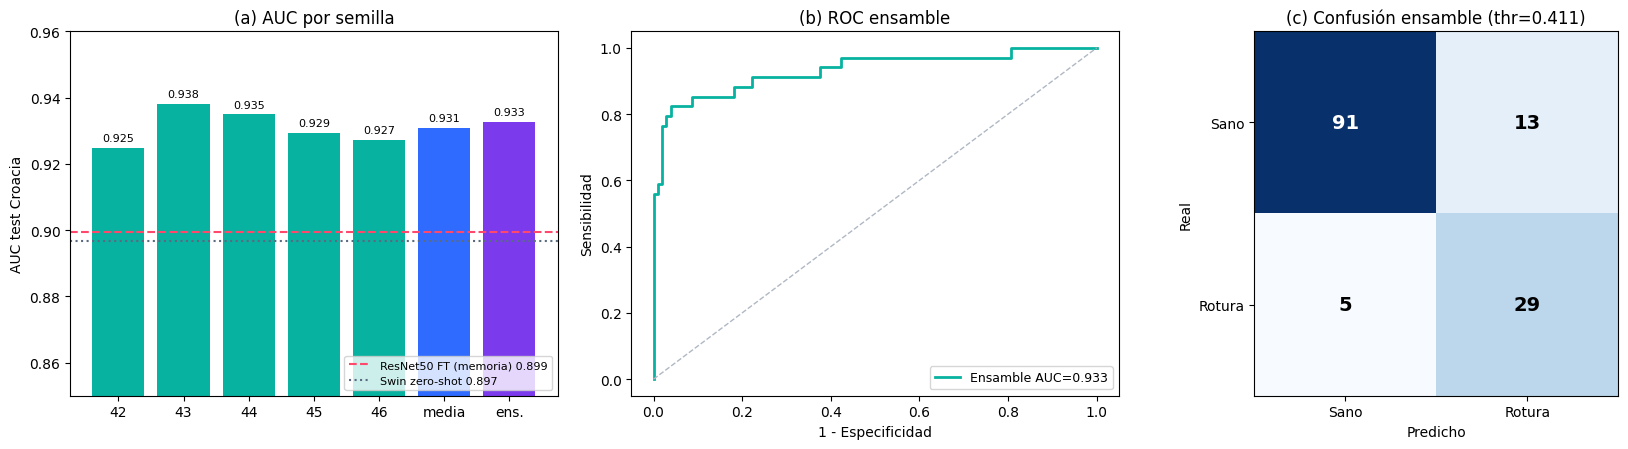

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

# (a) AUC por semilla + media + ensamble, con líneas de referencia
ax = axes[0]
labels = [str(r['seed']) for r in runs] + ['media', 'ens.']
vals = aucs + [np.mean(aucs), ens_auc]
colors = ['#07b3a0'] * len(runs) + ['#2f6bff', '#7c3aed']
ax.bar(labels, vals, color=colors)
ax.axhline(0.8993, ls='--', c='#ff486b', lw=1.5, label='ResNet50 FT (memoria) 0.899')
ax.axhline(ZERO_SHOT_AUC, ls=':', c='#5a6b81', lw=1.5, label=f'Swin zero-shot {ZERO_SHOT_AUC:.3f}')
ax.set_ylim(0.85, 0.96); ax.set_ylabel('AUC test Croacia'); ax.set_title('(a) AUC por semilla')
ax.legend(fontsize=8, loc='lower right')
for i, v in enumerate(vals):
    ax.text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=8)

# (b) Curva ROC del ensamble
ax = axes[1]
fpr, tpr, _ = roc_curve(ty, ens_test)
ax.plot(fpr, tpr, c='#07b3a0', lw=2, label=f'Ensamble AUC={ens_auc:.3f}')
ax.plot([0, 1], [0, 1], ls='--', c='#b0b8c4', lw=1)
ax.set_xlabel('1 - Especificidad'); ax.set_ylabel('Sensibilidad')
ax.set_title('(b) ROC ensamble'); ax.legend(fontsize=9, loc='lower right')

# (c) Matriz de confusión del ensamble
ax = axes[2]
ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Sano', 'Rotura'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Sano', 'Rotura'])
ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
ax.set_title(f'(c) Confusión ensamble (thr={thr:.3f})')
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, int(v), ha='center', va='center',
            color='white' if v > cm.max() / 2 else 'black', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT / 'finetune_v2_resumen.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Conclusión

- El Swin-Tiny **nunca** partió de 0.85 en zero-shot: su AUC sin reentrenar sobre el
  test de Croacia es ~0.897 (0.882 sobre el conjunto completo de 917). El 0.852→0.899 de
  la memoria es del **ResNet50**, no del Swin.
- El fine-tuning en el dominio de Croacia sube el AUC del Swin a **~0.93** de forma
  **estable entre semillas** (0.925–0.938, σ≈0.005), superando tanto su propio zero-shot
  como el fine-tuning del ResNet50 de la memoria (0.899).
- **Caveat:** el test-138 es un split held-out concreto y algo benévolo (para el ResNet
  el zero-shot pasa de 0.775 sobre los 917 a 0.852 sobre este test). El número debe
  citarse siempre como *"sobre el subconjunto de test de Croacia"*. La comparación
  Swin vs ResNet es limpia porque el split favorece a ambos por igual.
- Para una cifra de generalización comparable al conjunto completo haría falta
  validación cruzada (k-fold) sobre Croacia.